# Lecture 6 — Spatial Heterogeneity and Calibration

**Computational Methods for Heterogeneous-Agent Macro**

Jeffrey Sun

## 1. Setup

In [19]:
using Pkg
Pkg.activate("..")
Pkg.instantiate()
using HouseholdStages
using Printf
using Plots, Plots.PlotMeasures

  Activating project at `~/projects/research/CV is all you need`


## 2. A Simple Spatial Model

There are three locations $j\in\{1,2,3\}$ populated by forward-looking households who can save. Each location has exogenous productivities $A_1 > A_2 > A_3$. Each location produces a single, costlessly-tradable, perfectly-substitutable numeraire good with Cobb-Douglas technology
$$Y_j = A_j K_j^{\alpha} L_j^{1-\alpha}.$$

They form a **small open economy.** Capital flows freely across locations and with the rest of the world, so that **$r$ is exogenous**. Within the country, MPK equalization across locations pins $K_j / L_j$ given $(r, A_j)$, and wages then satisfy
$$w_j = (1-\alpha)\, A_j\, \bigl(\tfrac{\alpha A_j}{r+\delta}\bigr)^{\alpha/(1-\alpha)}.$$

We close the model differently than Aiyagari. $r$ is set by the world bond market, so $K$ is pinned down from the start and there is no need to solve for equilibrium.

The outer loop of interest we will explore is the **calibration** of preference shifters $\alpha = (\alpha_1, \alpha_2, \alpha_3)$.

Households are heterogeneous in **wealth** and **location** only. There are no idiosyncratic income shocks. The household stages are:

1. **Migration** — choose where to live next period, given the current location.
2. **Receive income** — wealth update with the current location's wage.
3. **Consumption-savings** — choose next-period wealth.

The chain is
$$\text{Migration} \circ \text{WealthChange} \circ \text{ConsumptionSavings}.$$

**Note:** Adding idiosyncratic productivity shocks would be as simple as adding an additional stage. Try it for yourself!

### 2.1 Parameters and target shares

Migration cost $C[i, j]$ is as though locations 1-3 lie on a line, with 2 between 1 and 3.

We are pretending that the empirically observed shares are `s_data = (0.30, 0.30, 0.40)`.

In [2]:
@kwdef struct SpatialParams
    β::Float64 = 0.96
    σ::Float64 = 1.5
    α::Float64 = 0.36
    δ::Float64 = 0.08
    r::Float64 = 0.03                          # world interest rate (exogenous)
    A::NTuple{3,Float64} = (1.20, 1.00, 0.85)  # productivities
    # Migration cost matrix C[i, j] (origin → destination).
    C_base::Matrix{Float64} = [0.0 0.5 1.0;
                               0.5 0.0 0.5;
                               1.0 0.5 0.0]
    η_logit::Float64 = 1.5                     # Gumbel scale
    # Initial guess for the (α₂, α₃) calibration iterate; α₁ ≡ 0.
    α_init::NTuple{2,Float64} = (0.0, 0.0)
    N_w::Int       = 250
    w_min::Float64 = 0.0
    w_max::Float64 = 25.0
end
Base.Broadcast.broadcastable(p::SpatialParams) = Ref(p)

const LOC_NAMES = (:loc1, :loc2, :loc3)
loc_idx(sym::Symbol) = findfirst(==(sym), LOC_NAMES)

const s_data = [0.30, 0.30, 0.40]
p = SpatialParams()
@printf "β=%.2f, σ=%.2f, α=%.2f, δ=%.2f, r=%.4f\n" p.β p.σ p.α p.δ p.r
@printf "A = (%.2f, %.2f, %.2f);  η_logit = %.2f\n" p.A[1] p.A[2] p.A[3] p.η_logit
println("target shares = ", s_data)

β=0.96, σ=1.50, α=0.36, δ=0.08, r=0.0300
A = (1.20, 1.00, 0.85);  η_logit = 1.50
target shares = [0.3, 0.3, 0.4]


### 2.2 Wages from the world rate

`spatial_wage(r, A_j, p)` implements $w_j = (1-\alpha) A_j (\alpha A_j / (r+\delta))^{\alpha/(1-\alpha)}$. We broadcast it over `p.A` to get the length-3 wage vector `w_vec`. The env we pass to the household block will carry `w_vec` and the current calibration iterate $\alpha$ (also length 3) — that comes once we've built the chain.

In [3]:
function spatial_wage(r, A_j, p)
    return (1 - p.α) * A_j * (p.α * A_j / (r + p.δ))^(p.α / (1 - p.α))
end

w_vec = spatial_wage.(p.r, p.A, p)
@printf "Wages: w = (%.4f, %.4f, %.4f)\n" w_vec[1] w_vec[2] w_vec[3]
@printf "Ratio w[1]/w[3] = %.3f (productivity ratio A[1]/A[3] = %.3f)\n" w_vec[1]/w_vec[3] p.A[1]/p.A[3]

Wages: w = (1.6578, 1.2469, 0.9672)
Ratio w[1]/w[3] = 1.714 (productivity ratio A[1]/A[3] = 1.412)


### 2.3 The household block

Three stages. The migration stage's amenity field is a length-3 `Vector{Float64}` you supply at construction — with the convention $\alpha_1 \equiv 0$ pinning location utility (only differences are identified). We hold a *handle* to this vector. The calibration loop in §4 mutates it in place between solves; `backward!` reads the current values on each pass without env-routing or Spec rebuilds.

In [4]:
_u_crra(c, ::Val{1})           = log(c)
_u_crra(c, ::Val{σv}) where σv = (c^(1 - σv)) / (1 - σv)
u_crra(c, valσ::Val) = c < 0 ? -Inf : _u_crra(c, valσ)

function spatial_household(p::SpatialParams; α::Vector{Float64}=zeros(3))
    layout = StateLayout(
        StateAxis(:wealth, continuous_grid(p.w_min, p.w_max; length=p.N_w, spacing=:log)),
        StateAxis(:location, categorical(collect(LOC_NAMES))),
    )

    # Amenity vector: shared mutable handle. Mutating `α` after construction
    # changes what `backward!` sees on the next call.
    migration = MigrationStage(layout; migration_cost=p.C_base, amenity=α, ε=p.η_logit)

    income = WealthChangeStage(layout; wealth_post = function (cell; env)
        return (1 + env.r) * cell.wealth + env.w[loc_idx(cell.location)]
    end)

    savings = ConsumptionSavingsStage(layout; β=p.β, utility=(cell, c; env) -> u_crra(c, Val(p.σ)), monotone_search=:divide_conquer)

    hh = migration ∘ income ∘ savings

    return define_moments!(hh;
        K_total = at_end(integrand=(cell; env) -> cell.wealth, reduce=sum),
        L       = at_end(integrand=(cell; env) -> Float64[cell.location == j for j in LOC_NAMES], reduce=sum),
    )
end

α  = zeros(3)
hh = spatial_household(p; α)
dims = layout_size(input_layout(hh))
@printf "Layout: wealth %d × location %d = %d cells\n" dims[1] dims[2] prod(dims)

Layout: wealth 250 × location 3 = 750 cells


### 2.4 What's inside `hh`?

A quick peek at the migration stage's Spec and Buffer. The Spec carries the cost matrix and a reference to the amenity vector `α`; the Buffer carries the per-cell choice-probability tensor `choice_prob` — the migration stage's "memory" — repopulated by the log-sum-exp on every `backward!`.

In [5]:
mig = hh.spec.stages[1]
mig_buf = hh.buffer.stages[1]
@show typeof(mig)
@show typeof(mig.amenity)                       # Vector{Float64}
@show mig.amenity === α                          # same array — mutating α mutates the Spec's view
@show size(mig_buf.kernel.choice_prob)          # (N_w, 3, 3): per (wealth, origin), per destination

typeof(mig) = HouseholdStages.MigrationStageSpec{Matrix{Float64}, Vector{Float64}, Float64}
typeof(mig.amenity) = Vector{Float64}
mig.amenity === α = true
size(mig_buf.kernel.choice_prob) = (250, 3, 3)


(250, 3, 3)

## 3. Solving the household at $\alpha = 0$

A **demo run** at the initial guess $\alpha = 0$ — *before* the calibration loop kicks in. Choice probabilities depend only on wages and the migration cost. `loc1` has the highest wage; we expect it to attract the largest population share. The §4 calibration will then bend $\alpha$ to match the data.

In [6]:
"Solve the household block. The amenity vector currently in `hh` (the same `α` constructed above) determines the migration preferences; mutate `α` to change them."
function solve_household(hh, p; V_init=nothing, Λ_init=nothing)
    env = make_env(hh; r=p.r, w=spatial_wage.(p.r, p.A, p))
    (;V, Λ, moments) = solve_steady_state_given_env!(hh, env; V_init, Λ_init)
    shares = moments.L ./ sum(moments.L)
    return (; V, Λ, env, moments, shares)
end

α .= 0.0                                 # uncalibrated baseline
out0 = solve_household(hh, p)
@printf "mass conservation: ΣΛ = %.10f\n" sum(out0.Λ)
@printf "Population shares (uncalibrated): (%.3f, %.3f, %.3f)\n" out0.shares[1] out0.shares[2] out0.shares[3]
@printf "Total wealth K_total = %.4f\n" out0.moments.K_total

mass conservation: ΣΛ = 1.0000000000
Population shares (uncalibrated): (0.387, 0.365, 0.248)
Total wealth K_total = 0.7546


The high-productivity region `loc1` is overpopulated relative to the data; `loc3` is underpopulated. Something is keeping people in `loc3` that the model — with $\alpha = 0$ — does not see. That something is what we will calibrate.


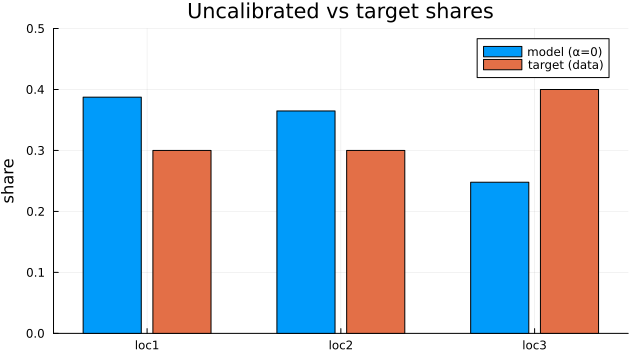

In [7]:
xs = 1:3
plt_init = plot(title="Uncalibrated vs target shares", ylabel="share",
                xticks=(xs, ["loc1", "loc2", "loc3"]),
                ylims=(0.0, 0.5), legend=:topright, size=(640, 360))
bar!(plt_init, xs .- 0.18, out0.shares; bar_width=0.30, label="model (α=0)")
bar!(plt_init, xs .+ 0.18, s_data;      bar_width=0.30, label="target (data)")

## 4. Calibration by damped log-share update

The wage-only model misses the data on `loc3`. We need preference shifters $(\alpha_2, \alpha_3)$ — recall $\alpha_1 \equiv 0$ — such that the stationary population shares equal `s_data`. Three steps: understand the map $\alpha \to \text{shares}$, write down its (approximate) inverse, then run the loop.

### 4.1 The map $\alpha \to$ shares

Intuition: a larger amenity $\alpha_j$ makes destination $j$ more attractive, so more households migrate there in steady state. Concretely, bumping $\alpha_3$ from 0 to +0.5 should shift mass *into* `loc3` and *out of* `loc1` / `loc2`. Let's check.

In [8]:
α .= [0.0, 0.0, 0.5]                     # bump α₃; out0 stays cached from the previous solve
out_bump = solve_household(hh, p)
α .= 0.0                                 # restore baseline for the calibration loop below
@printf "α₃ = 0.0:  shares = (%.3f, %.3f, %.3f)\n" out0.shares[1] out0.shares[2] out0.shares[3]
@printf "α₃ = 0.5:  shares = (%.3f, %.3f, %.3f)\n" out_bump.shares[1] out_bump.shares[2] out_bump.shares[3]
@printf "Δ on loc3: %+.3f\n" out_bump.shares[3] - out0.shares[3]

α₃ = 0.0:  shares = (0.387, 0.365, 0.248)
α₃ = 0.5:  shares = (0.330, 0.326, 0.345)
Δ on loc3: +0.097


### 4.2 Inverting the map — a damped log-share update

In **static** logit, larger amenity $\alpha_j$ shifts mass toward $j$ proportionally to $\log s_j$. The update
$$\alpha_j \;\leftarrow\; \alpha_j \;+\; \eta_{\text{logit}} \cdot \bigl(\log s_j^{\text{data}} - \log s_j^{\text{model}}\bigr)$$
is a damped step toward the fixed point in the log-share gap. In our **dynamic** model, $V_j$ also depends on $\alpha$ through future migration value, so the static formula is no longer an exact inversion — but the same update remains a useful, empirically conservative, fixed-point iteration. **In code:** scale by `update_speed` $\in (0, 1]$ for safety, drop the gradient of $\alpha_1$ to enforce the normalization, and let it run.

In [9]:
"Calibrate the amenity shifters by a damped log-share update. Mutates the `α` vector in place — the same one `hh` references."
function calibrate_shifters!(hh, p, α, s_data; update_speed=0.1, rtol=5e-3, maxiter=100, verbosity=0)
    local V, Λ, shares
    V = nothing
    Λ = nothing

    α[1] = 0.0
    α[2] = p.α_init[1]
    α[3] = p.α_init[2]
    α_history   = [copy(α)]
    gap_history = Vector{Float64}[]

    err = Inf
    iters = 0
    while err >= rtol
        out = solve_household(hh, p; V_init=V, Λ_init=Λ)
        (;V, Λ, shares) = out

        gap = log.(s_data) .- log.(max.(shares, 1e-8))
        err = maximum(abs, gap)
        push!(gap_history, copy(gap))

        # Damped log-share update; renormalize α[1] = 0
        α .+= update_speed * p.η_logit .* gap
        α .-= α[1]
        push!(α_history, copy(α))

        verbosity >= 1 && @printf "  iter %d: shares = (%.3f, %.3f, %.3f), α = (%.3f, %.3f, %.3f), ‖gap‖∞ = %.4f\n" iters shares[1] shares[2] shares[3] α[1] α[2] α[3] err
        iters = iters + 1
        iters > maxiter && error("calibrate_shifters! did not converge in $maxiter iterations")
    end

    return (; α, V, Λ, shares, α_history, gap_history, iters)
end

calibrate_shifters!

### 4.3 Run the calibration

The loop starts at $\alpha = 0$ (where `loc3` is underpopulated), takes one damped log-share step, re-solves the household, repeats. Convergence is geometric.

In [10]:
calib = calibrate_shifters!(hh, p, α, s_data; verbosity=1)
@printf "\nFinal α = (%.4f, %.4f, %.4f) in %d iterations\n" calib.α[1] calib.α[2] calib.α[3] calib.iters
@printf "Final shares: (%.3f, %.3f, %.3f) vs target (%.3f, %.3f, %.3f)\n" calib.shares[1] calib.shares[2] calib.shares[3] s_data[1] s_data[2] s_data[3]

  iter 0: shares = (0.387, 0.365, 0.248), α = (0.000, 0.009, 0.110), ‖gap‖∞ = 0.4788
  iter 1: shares = (0.375, 0.359, 0.266), α = (0.000, 0.016, 0.204), ‖gap‖∞ = 0.4061
  iter 2: shares = (0.364, 0.353, 0.284), α = (0.000, 0.020, 0.285), ‖gap‖∞ = 0.3442
  iter 3: shares = (0.354, 0.347, 0.299), α = (0.000, 0.023, 0.354), ‖gap‖∞ = 0.2923
  iter 4: shares = (0.346, 0.342, 0.312), α = (0.000, 0.024, 0.412), ‖gap‖∞ = 0.2481
  iter 5: shares = (0.339, 0.338, 0.324), α = (0.000, 0.025, 0.462), ‖gap‖∞ = 0.2109
  iter 6: shares = (0.332, 0.333, 0.334), α = (0.000, 0.024, 0.504), ‖gap‖∞ = 0.1794
  iter 7: shares = (0.327, 0.329, 0.343), α = (0.000, 0.023, 0.540), ‖gap‖∞ = 0.1529
  iter 8: shares = (0.323, 0.326, 0.351), α = (0.000, 0.022, 0.571), ‖gap‖∞ = 0.1301
  iter 9: shares = (0.319, 0.323, 0.358), α = (0.000, 0.020, 0.597), ‖gap‖∞ = 0.1110
  iter 10: shares = (0.316, 0.320, 0.364), α = (0.000, 0.018, 0.619), ‖gap‖∞ = 0.0946
  iter 11: shares = (0.313, 0.318, 0.369), α = (0.000, 0.016, 0.

### 4.4 Convergence diagnostics

The log-share gap collapses geometrically; the shifter trajectory rises monotonically toward the fixed point.

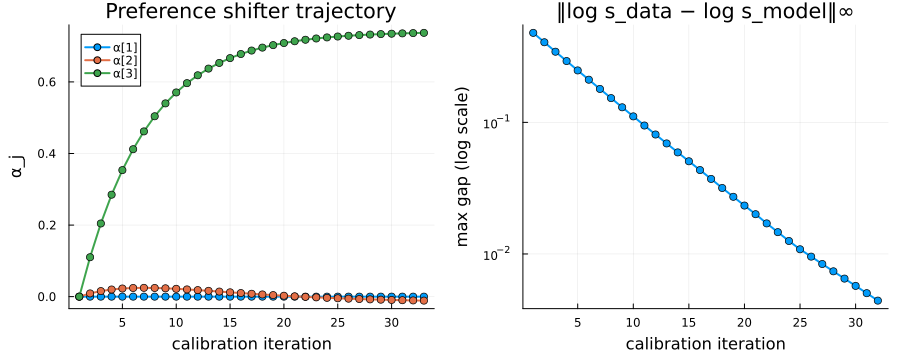

In [21]:
αs   = hcat(calib.α_history...)
gaps = hcat(calib.gap_history...)

plt_α   = plot(1:size(αs, 2), αs',
               label=["α[1]" "α[2]" "α[3]"], marker=:circle, linewidth=2,
               xlabel="calibration iteration", ylabel="α_j",
               title="Preference shifter trajectory")

plt_gap = plot(1:size(gaps, 2), maximum.(abs, eachcol(gaps)),
               marker=:circle, linewidth=2, yaxis=:log,
               xlabel="calibration iteration", ylabel="max gap (log scale)",
               title="‖log s_data − log s_model‖∞", legend=false)

plot(plt_α, plt_gap; layout=(1, 2), size=(900, 360), bottom_margin=5mm, left_margin=5mm)

### 4.5 Final shares: uncalibrated, calibrated, target

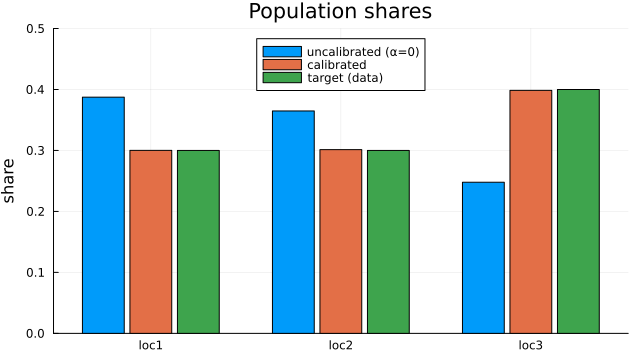

In [22]:
xs = 1:3
plt_final = plot(title="Population shares", ylabel="share",
                 xticks=(xs, ["loc1", "loc2", "loc3"]),
                 ylims=(0.0, 0.5), legend=:top, size=(640, 360))
bar!(plt_final, xs .- 0.25, out0.shares;  bar_width=0.22, label="uncalibrated (α=0)")
bar!(plt_final, xs,         calib.shares; bar_width=0.22, label="calibrated")
bar!(plt_final, xs .+ 0.25, s_data;       bar_width=0.22, label="target (data)")

## 5. Wealth distribution by location

Given location, how is wealth distributed? With no income heterogeneity, the only source of wealth heterogeneity is differences in location *histories*.

The low-wage, high-amenity location has the highest wealth inequality. Economically interesting! Can you think of why this might be? Does this mechanism hold in the data?

In [23]:
"Compute the Gini coefficient of a discrete distribution."
function _gini(values::AbstractVector, mass::AbstractVector)
    total = sum(mass)
    total ≤ 0 && return NaN
    perm = sortperm(values)
    v    = values[perm]
    p    = mass[perm] ./ total
    cumpop    = vcat(0.0, cumsum(p))
    cumwealth = vcat(0.0, cumsum(v .* p) ./ sum(v .* p))
    area_under_lorenz = sum(diff(cumpop) .* (cumwealth[2:end] .+ cumwealth[1:end-1]) ./ 2)
    return 1 - 2 * area_under_lorenz
end

bgrid = input_layout(hh).axes[1].kind.grid
Λ_ss  = calib.Λ
w_vec = spatial_wage.(p.r, p.A, p)

println("location |  wage  |  share | mean b  | Pr(b=0) |  Gini")
println("---------|--------|--------|---------|---------|--------")
for j in 1:3
    mass_j  = @view Λ_ss[:, j]
    share_j = sum(mass_j)
    mean_w  = sum(bgrid .* mass_j) / share_j
    p_atbc  = mass_j[1] / share_j
    gini_j  = _gini(bgrid, mass_j)
    @printf "%-8s | %.4f | %.3f  | %.4f  |  %.3f  | %.3f\n" string(LOC_NAMES[j]) w_vec[j] share_j mean_w p_atbc gini_j
end

location |  wage  |  share | mean b  | Pr(b=0) |  Gini
---------|--------|--------|---------|---------|--------
loc1     | 1.6578 | 0.300  | 1.1611  |  0.000  | 0.279
loc2     | 1.2469 | 0.301  | 0.7426  |  0.000  | 0.408
loc3     | 0.9672 | 0.398  | 0.4866  |  0.184  | 0.550


### 6.1 Conditional wealth distribution by location

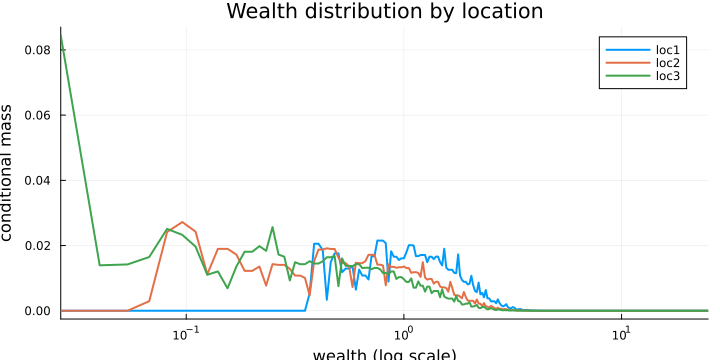

In [33]:
Λ_ss_smoothed = Λ_ss[3:end,:] .+ Λ_ss[2:end-1,:] .+ Λ_ss[1:end-2,:]           # Smooth Λ_ss slightly to make up for interpolation noise

Λ_cond = Λ_ss_smoothed ./ sum(Λ_ss_smoothed; dims=1)   # normalize each location column to sum to 1
plot(bgrid[3:end], Λ_cond;
     labels=["loc1" "loc2" "loc3"],
     xlims=(bgrid[3], bgrid[end]),
     xscale=:log10,
     xlabel="wealth (log scale)", ylabel="conditional mass",
     title="Wealth distribution by location",
     linewidth=2, size=(720, 360))